In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [5]:
births = pd.read_csv('births.csv')
print(births.head())

   year  month  day gender  births
0  1969      1  1.0      F    4046
1  1969      1  1.0      M    4440
2  1969      1  2.0      F    4454
3  1969      1  2.0      M    4548
4  1969      1  3.0      F    4548


In [17]:
births

,year,month,day,gender,births,decade
0,1969,1,1.0,F,4046,1960
1,1969,1,1.0,M,4440,1960
2,1969,1,2.0,F,4454,1960
3,1969,1,2.0,M,4548,1960
4,1969,1,3.0,F,4548,1960
...,...,...,...,...,...,...
15542,2008,10,NaN,M,183219,2000
15543,2008,11,NaN,F,158939,2000
15544,2008,11,NaN,M,165468,2000
15545,2008,12,NaN,F,173215,2000


In [20]:
births['day'] = births['day'].fillna(0)
births['day']

0        1.0
1        1.0
2        2.0
3        2.0
4        3.0
        ... 
15542    0.0
15543    0.0
15544    0.0
15545    0.0
15546    0.0
Name: day, Length: 15547, dtype: float64

In [22]:
births['decade'] = 10 * (births['year'] // 10)
print(births.head())


   year  month  day gender  births  decade
0  1969      1  1.0      F    4046    1960
1  1969      1  1.0      M    4440    1960
2  1969      1  2.0      F    4454    1960
3  1969      1  2.0      M    4548    1960
4  1969      1  3.0      F    4548    1960


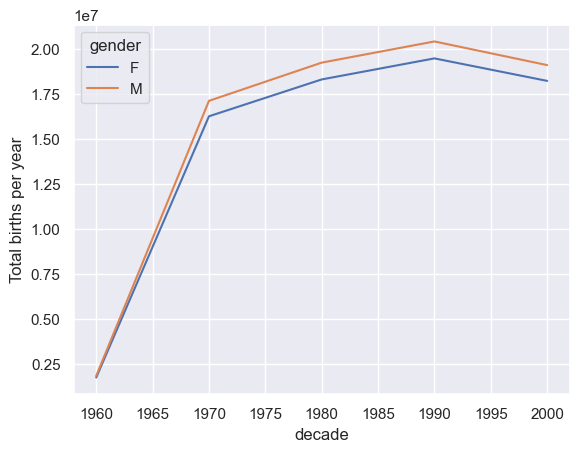

In [23]:
sns.set_theme()
birth_decade = births.pivot_table('births', index='decade', columns='gender', aggfunc='sum')
birth_decade.plot()
plt.ylabel("Total births per year")
plt.show()

In [24]:
quantiles = np.percentile(births['births'], [25, 50, 75])
mu = quantiles[1]
sig = 0.74 * (quantiles[2] - quantiles[0])
print(sig)

689.31


In [26]:
births = births.query("(births > @mu - 5 * @sig) & (births < @mu + 5 * @sig)")

In [29]:
births.index = pd.to_datetime(
    10000 * births.year +
    100 * births.month +
    births.day,
    format='%Y%m%d'
)

In [36]:
births['dayofweek'] = births.index.dayofweek

In [35]:
births.index.weekday

Index([2, 2, 3, 3, 4, 4, 5, 5, 6, 6,
       ...
       1, 1, 2, 2, 3, 3, 4, 4, 5, 5],
      dtype='int32', length=14610)

<Axes: xlabel='dayofweek'>

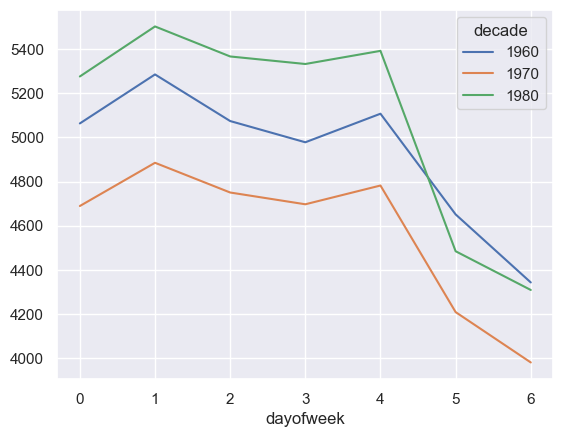

In [37]:
births.pivot_table(
    'births',
    index='dayofweek',
    columns='decade',
    aggfunc='mean'
).plot()

In [40]:
births_month = births.pivot_table(
    'births',
    [births.index.month, births.index.day]
)

In [45]:
births_month.index = [
    datetime(2012, month, day) for (month, day) in births_month.index
]
print(births_month.head())

              births
2012-01-01  4009.225
2012-01-02  4247.400
2012-01-03  4500.900
2012-01-04  4571.350
2012-01-05  4603.625


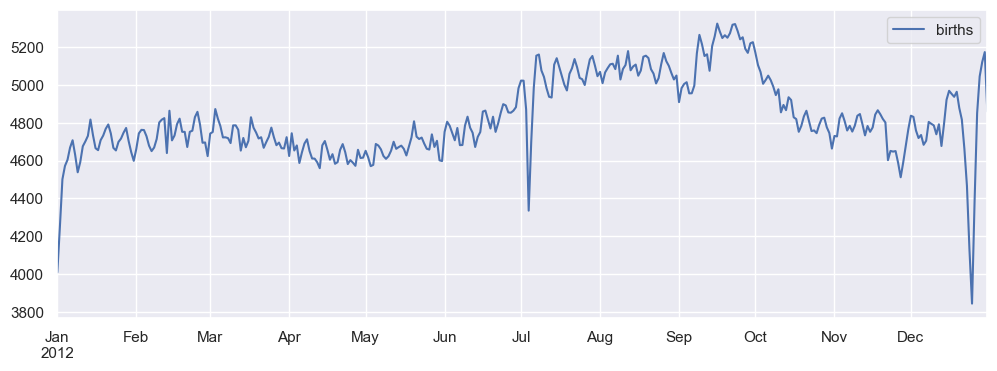

In [46]:
fig, ax = plt.subplots(figsize=(12,4))
births_month.plot(ax=ax)
plt.show()